訓練資料形狀: (885, 2, 1, 128)
訓練開始，使用設備：cuda
[Epoch 1/50] [Batch 0/55] [Loss: 1.1529]
[Epoch 1/50] [Batch 20/55] [Loss: 1.1909]
[Epoch 1/50] [Batch 40/55] [Loss: 1.1265]
[Epoch 1/50] Average Loss: 1.1495
[Epoch 2/50] [Batch 0/55] [Loss: 0.7255]
[Epoch 2/50] [Batch 20/55] [Loss: 0.9628]
[Epoch 2/50] [Batch 40/55] [Loss: 0.9036]
[Epoch 2/50] Average Loss: 1.0174
[Epoch 3/50] [Batch 0/55] [Loss: 0.8650]
[Epoch 3/50] [Batch 20/55] [Loss: 0.7975]
[Epoch 3/50] [Batch 40/55] [Loss: 1.8226]
[Epoch 3/50] Average Loss: 0.7631
[Epoch 4/50] [Batch 0/55] [Loss: 0.6969]
[Epoch 4/50] [Batch 20/55] [Loss: 0.8075]
[Epoch 4/50] [Batch 40/55] [Loss: 0.7632]
[Epoch 4/50] Average Loss: 0.6694
[Epoch 5/50] [Batch 0/55] [Loss: 0.4372]
[Epoch 5/50] [Batch 20/55] [Loss: 0.5795]
[Epoch 5/50] [Batch 40/55] [Loss: 0.5469]
[Epoch 5/50] Average Loss: 0.6663
[Epoch 6/50] [Batch 0/55] [Loss: 0.6848]
[Epoch 6/50] [Batch 20/55] [Loss: 0.5530]
[Epoch 6/50] [Batch 40/55] [Loss: 0.6338]
[Epoch 6/50] Average Loss: 0.5946
[Epoch

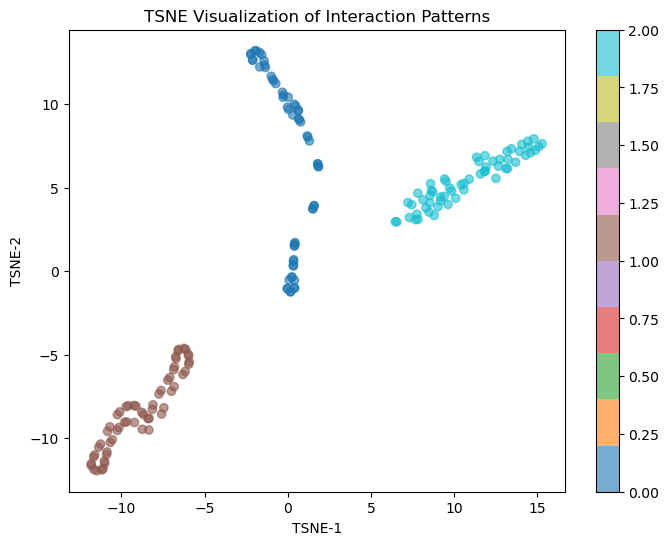

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ===============================
# 資料集與增強方法
# ===============================
class MultiTimeSeriesDataset(Dataset):
    def __init__(self, data, labels=None):
        # data shape: (N, num_series, channels, series_length)
        # labels: 每個樣本的交互模式標籤（可選）
        if isinstance(data, np.ndarray):
            self.data = torch.from_numpy(data).float()
        else:
            self.data = data.float()
        self.labels = torch.tensor(labels, dtype=torch.long) if labels is not None else None

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        if self.labels is not None:
            return self.data[idx], self.labels[idx]
        return self.data[idx]

def strong_augmentation(x, noise_std=0.05):
    """強增強：加入較大噪聲與隨機縮放"""
    noise = torch.randn_like(x) * noise_std
    scale = torch.empty(x.size(0), 1, 1, 1, device=x.device).uniform_(0.8, 1.2)
    return x * scale + noise

def weak_augmentation(x, noise_std=0.01):
    """弱增強：僅加入微小噪聲"""
    noise = torch.randn_like(x) * noise_std
    return x + noise

# ===============================
# 對比損失函數
# ===============================
def interaction_contrast_loss(z_set, labels, temperature=0.5):
    """
    交互模式的對比損失
    z_set: [N, num_series, d]，潛在表徵
    labels: [N]，每個樣本的交互模式標籤
    """
    N, num_series, d = z_set.shape
    z_flat = z_set.view(N, -1)  # [N, num_series * d]
    z_norm = F.normalize(z_flat, dim=1)
    similarity_matrix = torch.matmul(z_norm, z_norm.T) / temperature
    mask = (labels.unsqueeze(1) == labels.unsqueeze(0)).float()
    mask = mask - torch.eye(N, device=z_set.device)  # 排除自身
    exp_sim = torch.exp(similarity_matrix)
    pos_sim = exp_sim * mask
    neg_sim = exp_sim * (1 - mask)
    loss = -torch.log((pos_sim.sum(dim=1) + 1e-8) / (neg_sim.sum(dim=1) + pos_sim.sum(dim=1) + 1e-8))
    return loss.mean()

# ===============================
# 模型架構：Encoder
# ===============================
class MultiTimeSeriesEncoder(nn.Module):
    def __init__(self, num_series=2, channels=1, series_length=128, latent_dim=100):
        super(MultiTimeSeriesEncoder, self).__init__()
        self.num_series = num_series
        self.hidden_dim = 64
        # 每個時間序列獨立的卷積層
        self.conv = nn.ModuleList([nn.Sequential(
            nn.Conv1d(channels, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv1d(32, self.hidden_dim, kernel_size=5, stride=2, padding=2),
            nn.ReLU(inplace=True)
        ) for _ in range(num_series)])
        # 全局池化與全連接層
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.ModuleList([nn.Linear(self.hidden_dim, latent_dim) for _ in range(num_series)])

    def forward(self, x):
        # x: [batch, num_series, channels, length]
        batch_size = x.size(0)
        z_list = []
        for i in range(self.num_series):
            x_i = x[:, i, :, :]  # [batch, channels, length]
            features = self.conv[i](x_i)  # [batch, hidden_dim, L]
            global_feat = self.pool(features).squeeze(-1)  # [batch, hidden_dim]
            z_i = self.fc[i](global_feat)  # [batch, latent_dim]
            z_list.append(z_i)
        z_set = torch.stack(z_list, dim=1)  # [batch, num_series, latent_dim]
        return z_set

# ===============================
# TS-TCC 主架構
# ===============================
class TS_TCC_Multi:
    def __init__(self, dataset, num_series=2, latent_dim=100, series_length=128, channels=1, 
                 batch_size=32, lr=1e-4, temperature=0.5):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.num_series = num_series
        self.latent_dim = latent_dim
        self.series_length = series_length
        self.channels = channels
        self.batch_size = batch_size
        self.lr = lr
        self.temperature = temperature

        # 初始化模型與數據加載器
        self.encoder = MultiTimeSeriesEncoder(num_series, channels, series_length, latent_dim).to(self.device)
        self.dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
        self.optimizer = optim.Adam(self.encoder.parameters(), lr=lr)

    def train(self, num_epochs=50):
        """訓練過程"""
        print(f"訓練開始，使用設備：{self.device}")
        for epoch in range(num_epochs):
            total_loss = 0
            for i, (data, labels) in enumerate(self.dataloader):
                data = data.to(self.device)
                labels = labels.to(self.device)

                # 生成增強視圖
                strong_view = strong_augmentation(data)
                weak_view = weak_augmentation(data)

                # 編碼
                z_strong = self.encoder(strong_view)
                z_weak = self.encoder(weak_view)

                # 計算對比損失
                loss_strong = interaction_contrast_loss(z_strong, labels, self.temperature)
                loss_weak = interaction_contrast_loss(z_weak, labels, self.temperature)
                loss = (loss_strong + loss_weak) / 2

                # 優化
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                total_loss += loss.item()

                if i % 20 == 0:
                    print(f"[Epoch {epoch+1}/{num_epochs}] [Batch {i}/{len(self.dataloader)}] "
                          f"[Loss: {loss.item():.4f}]")
            avg_loss = total_loss / len(self.dataloader)
            print(f"[Epoch {epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}")
        print("訓練完成。")

    def get_latent(self, x):
        """獲取潛在表徵"""
        self.encoder.eval()
        with torch.no_grad():
            z_set = self.encoder(x.to(self.device))
        self.encoder.train()
        return z_set.cpu()

# ===============================
# 拓撲建構與視覺化
# ===============================
def tsne_visualize(model, test_data, labels):
    """使用 TSNE 視覺化潛在空間"""
    model.encoder.eval()
    all_latents = []
    all_labels = []
    for i in range(test_data.shape[0]):
        window = torch.from_numpy(test_data[i]).unsqueeze(0).float()  # [1, num_series, channels, length]
        z_set = model.get_latent(window)  # [1, num_series, latent_dim]
        z_flat = z_set.view(-1).numpy()  # [num_series * latent_dim]
        all_latents.append(z_flat)
        all_labels.append(labels[i])
    
    all_latents = np.array(all_latents)
    perplexity = min(30, len(all_latents) - 1)
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    latent_2d = tsne.fit_transform(all_latents)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=all_labels, cmap='tab10', alpha=0.6)
    plt.colorbar(scatter)
    plt.title("TSNE Visualization of Interaction Patterns")
    plt.xlabel("TSNE-1")
    plt.ylabel("TSNE-2")
    plt.show()

# ===============================
# 資料生成
# ===============================
def generate_interaction_series(length=1000, pattern_type=0):
    """生成不同交互模式的時間序列"""
    t = np.linspace(0, 4 * np.pi, length)
    series1 = np.zeros(length)
    series2 = np.zeros(length)
    if pattern_type == 0:  # 反向交互
        series1 = np.sin(t)
        series2 = -np.sin(t)
    elif pattern_type == 1:  # 平穩與震盪
        series1 = np.ones(length) * 0.5
        series2 = np.sin(t) * 0.5
    elif pattern_type == 2:  # 基線漂移
        series1 = np.ones(length)
        series2 = np.linspace(0, -1, length) + np.random.normal(0, 0.1, length)
    return np.stack([series1, series2], axis=0).astype(np.float32)

def sliding_window(data, window_size, stride):
    """滑窗分割時間序列"""
    num_series, length = data.shape
    num_windows = (length - window_size) // stride + 1
    windows = []
    for i in range(num_windows):
        start = i * stride
        window = data[:, start:start + window_size].reshape(num_series, 1, window_size)
        windows.append(window)
    return np.stack(windows, axis=0)

# ===============================
# 主程式
# ===============================
if __name__ == "__main__":
    # 參數設定
    window_size = 128
    stride = 32
    num_samples_per_pattern = 5

    # 生成訓練資料
    train_data_list = []
    train_labels_list = []
    for pattern in range(3):
        for _ in range(num_samples_per_pattern):
            series = generate_interaction_series(length=2000, pattern_type=pattern)
            windows = sliding_window(series, window_size, stride)
            train_data_list.append(windows)
            train_labels_list.extend([pattern] * windows.shape[0])
    train_data = np.concatenate(train_data_list, axis=0)
    train_labels = np.array(train_labels_list)
    print(f"訓練資料形狀: {train_data.shape}")

    # 建立資料集與模型
    dataset = MultiTimeSeriesDataset(train_data, train_labels)
    model = TS_TCC_Multi(dataset, num_series=2, latent_dim=100, series_length=window_size, 
                         channels=1, batch_size=16, lr=1e-4, temperature=0.5)

    # 訓練模型
    model.train(num_epochs=50)

    # 生成測試資料
    test_data_list = []
    test_labels_list = []
    for pattern in range(3):
        series = generate_interaction_series(length=2000, pattern_type=pattern)
        windows = sliding_window(series, window_size, stride)
        test_data_list.append(windows)
        test_labels_list.extend([pattern] * windows.shape[0])
    test_data = np.concatenate(test_data_list, axis=0)
    test_labels = np.array(test_labels_list)
    print(f"測試資料形狀: {test_data.shape}")

    # 視覺化潛在空間
    tsne_visualize(model, test_data, test_labels)